# Explainable AI Evaluation for ASR on Mozilla Common Voice

Fixed Kaggle-ready notebook.

Main fix in this version:
- `CV_ROOT` is set to `/kaggle/input`
- the notebook automatically searches for the real Common Voice folder containing `*.tsv` and `clips/`
- it supports split fallback: `validated → train → dev → test → other`
- metadata is loaded in chunks, so large Common Voice TSV files are safer
- validity uses CER-damage top-10% important phonemes, not the earlier broken string-vs-dict comparison


## 1. Install dependencies


In [70]:
# ============================================================
# CELL 1: Install Dependencies
# ============================================================
import subprocess
import sys


def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])


pip_install(
    'torchaudio>=2.1.0',
    'transformers>=4.35.0',
    'optimum',
    'lime',
    'scikit-learn',
    'jiwer',
    'pandas',
    'matplotlib',
    'tqdm',
    'soundfile',
    'librosa'
)

print('All packages installed.')


All packages installed.


## 2. Imports and configuration

Change `CV_LOCALE`, `CV_SPLIT`, and `MAX_UTTERANCES` here.

For the default English ASR model, keep `CV_LOCALE = 'en'`. If you use Bengali or another language, you must replace `MODEL_ID` with a model trained for that language.


In [54]:
import subprocess
print(subprocess.getoutput("find /kaggle/input -maxdepth 3 | head -60"))

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/organizations
/kaggle/input/datasets/organizations/mozillaorg
/kaggle/input/datasets/pypiahmad
/kaggle/input/datasets/pypiahmad/librispeech-asr-corpus


In [55]:
import subprocess
print(subprocess.getoutput("find /kaggle/input/datasets/organizations/mozillaorg -maxdepth 4"))

KeyboardInterrupt: 

In [71]:
# ============================================================
# CELL 2: Imports & Global Configuration
# ============================================================
import os
import glob
import re
import gc
import pickle
import random
import shutil
import time
import warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Tuple, Dict, Optional
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torchaudio
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
from sklearn.linear_model import Ridge
from jiwer import wer, cer, process_words
import IPython.display as ipd

warnings.filterwarnings('ignore')

# ── Common Voice dataset config ─────────────────────────────
WORK_DIR = Path('/kaggle/working')

# IMPORTANT:
# In Kaggle notebooks, added datasets are mounted under /kaggle/input/<dataset-slug>/.
# Do NOT use the Kaggle website/API path:
# /kaggle/input/datasets/organizations/mozillaorg/common-voice
#
# This notebook searches under /kaggle/input automatically and finds the folder
# containing both a Common Voice TSV file and clips/.
CV_ROOT = Path('/kaggle/input/datasets/organizations/mozillaorg/common-voice')

# CV_LOCALE removed: mozillaorg/common-voice dataset has no locale subfolder
# Available splits: cv-valid-train, cv-valid-dev, cv-valid-test,
#                   cv-other-train, cv-other-dev, cv-other-test
CV_SPLIT = 'cv-valid-test'

# ── Runtime/output config ───────────────────────────────────
CACHE_DIR = WORK_DIR / f'cache_common_voice_{CV_SPLIT}'
FIG_DIR   = WORK_DIR / 'figures_common_voice'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Set True only when you intentionally want to recompute everything
CLEAR_CACHE_ON_START = False
if CLEAR_CACHE_ON_START:
    shutil.rmtree(str(CACHE_DIR), ignore_errors=True)
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    print('Cache cleared.')

# ── Reproducibility ─────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ─────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── Hyperparameters ─────────────────────────────────────────
TARGET_SR       = 16_000
MAX_UTTERANCES  = 500      # start small; increase after the pipeline works
N_SAMPLES_LIME  = 500      # increase to 100/200 for stronger experiment
WS_WINDOW       = 5
TS_DUR_MS       = 90
K_VALUES        = [1, 3, 5]

# If True, keeps only rows where Common Voice gender is male/female.
# If False, unknown gender is kept as 'U'.
REQUIRE_KNOWN_GENDER = False

# ASR model. This one is English only.
MODEL_ID = 'facebook/wav2vec2-large-960h-lv60-self'

print('\nConfiguration complete.')
print(f'CV_ROOT   : {CV_ROOT}')
print(f'Exists    : {CV_ROOT.exists()}')
print(f'CV_SPLIT  : {CV_SPLIT}')
print(f'CACHE_DIR : {CACHE_DIR}')

if CV_ROOT.exists():
    print('\nTop-level folders under /kaggle/input:')
    for p in sorted(CV_ROOT.iterdir())[:50]:
        print(' ', p)
else:
    print('\nWARNING: /kaggle/input does not exist. Are you running inside Kaggle?')

Device: cuda
GPU : Tesla T4
VRAM: 15.6 GB

Configuration complete.
CV_ROOT   : /kaggle/input/datasets/organizations/mozillaorg/common-voice
Exists    : True
CV_SPLIT  : cv-valid-test
CACHE_DIR : /kaggle/working/cache_common_voice_cv-valid-test

Top-level folders under /kaggle/input:
  /kaggle/input/datasets/organizations/mozillaorg/common-voice/LICENSE.txt
  /kaggle/input/datasets/organizations/mozillaorg/common-voice/README.txt
  /kaggle/input/datasets/organizations/mozillaorg/common-voice/cv-invalid
  /kaggle/input/datasets/organizations/mozillaorg/common-voice/cv-invalid.csv
  /kaggle/input/datasets/organizations/mozillaorg/common-voice/cv-other-dev
  /kaggle/input/datasets/organizations/mozillaorg/common-voice/cv-other-dev.csv
  /kaggle/input/datasets/organizations/mozillaorg/common-voice/cv-other-test
  /kaggle/input/datasets/organizations/mozillaorg/common-voice/cv-other-test.csv
  /kaggle/input/datasets/organizations/mozillaorg/common-voice/cv-other-train
  /kaggle/input/dataset

## 3. Load Common Voice and run forced alignment

Common Voice uses `.tsv` metadata and `clips/*.mp3` audio. This cell automatically searches under `CV_ROOT` for a folder containing both `CV_SPLIT.tsv` and `clips/`.


In [72]:
# ============================================================
# CELL 3: Common Voice Loading + Forced Alignment
# mozillaorg/common-voice Kaggle dataset format:
#   <root>/cv-valid-train.csv   <- metadata (columns: filename, text, gender, age)
#   <root>/cv-valid-train/      <- audio folder containing *.mp3 files
# ============================================================
print(f'torchaudio version: {torchaudio.__version__}')


@dataclass
class Utterance:
    utt_id: str
    speaker_id: str
    gender: str
    audio_path: Path
    transcript: str
    waveform: Optional[torch.Tensor] = None
    sample_rate: int = TARGET_SR
    phonemes: List[Dict] = field(default_factory=list)
    words: List[Dict] = field(default_factory=list)


def normalize_cv_gender(g) -> str:
    g = str(g).strip().lower()
    if g in ['male', 'm']:
        return 'M'
    if g in ['female', 'f']:
        return 'F'
    return 'U'


def normalize_cv_transcript(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r'[“”"?!.,;:()\[\]{}]', ' ', text)
    text = re.sub(r'[-–—_/]', ' ', text)
    text = re.sub(r"[^a-z' ]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def load_common_voice_meta(
    root: Path,
    split: str = 'cv-valid-train',
    max_utts: Optional[int] = None,
    require_gender: bool = False,
) -> List[Utterance]:
    """
    Loader for the mozillaorg/common-voice Kaggle dataset.

    Dataset structure on Kaggle:
      /kaggle/input/datasets/mozillaorg/common-voice/
        cv-valid-train.csv        <- metadata
        cv-valid-train/           <- audio folder (mp3 files)
        cv-valid-dev.csv
        cv-valid-dev/
        cv-valid-test.csv
        cv-valid-test/
        cv-other-train.csv
        cv-other-train/

    CSV columns: filename, text, up_votes, down_votes, age, gender, accent, duration
    The 'filename' column contains values like: cv-valid-train/sample-000001.mp3
    """
    csv_path  = root / f'{split}.csv'
    audio_dir = root / split

    if not csv_path.exists():
        available = sorted(root.glob('*.csv'))
        raise FileNotFoundError(
            f'CSV not found: {csv_path}\n'
            f'Available CSVs under {root}:\n' +
            '\n'.join(f'  {p.name}' for p in available) +
            f'\n\nSet CV_SPLIT to one of: {[p.stem for p in available]}'
        )

    print(f'Reading : {csv_path}')
    print(f'Audio   : {audio_dir}')

    df = pd.read_csv(csv_path, keep_default_na=False)
    print(f'Columns : {df.columns.tolist()}')
    print(f'Total rows in CSV: {len(df)}')

    # Limit rows scanned to avoid iterating millions of rows for small max_utts
    scan_limit = (max_utts * 20) if max_utts else len(df)
    df = df.iloc[:scan_limit]

    utts = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f'Loading {split}'):
        filename = str(row.get('filename', '')).strip()
        sentence = normalize_cv_transcript(row.get('text', ''))

        if not filename or not sentence:
            continue

        # 'filename' is like 'cv-valid-train/sample-000001.mp3'
        # Try root/filename first (standard), then audio_dir/basename (fallback)
        audio_path = root / filename
        if not audio_path.exists():
            audio_path = audio_dir / Path(filename).name
        if not audio_path.exists():
            audio_path = audio_dir / audio_dir.name / Path(filename).name  # cv-valid-test/cv-valid-test/
        if not audio_path.exists():
            continue

        gender     = normalize_cv_gender(row.get('gender', ''))
        if require_gender and gender == 'U':
            continue

        age        = str(row.get('age', 'unknown')).strip()
        speaker_id = f'{age}_{gender}'
        utt_id     = Path(filename).stem

        utts.append(Utterance(
            utt_id=utt_id,
            speaker_id=speaker_id,
            gender=gender,
            audio_path=audio_path,
            transcript=sentence,
        ))

        if max_utts and len(utts) >= max_utts:
            break

    return utts


print('Scanning Common Voice ...')
utterances = load_common_voice_meta(
    CV_ROOT,
    split=CV_SPLIT,
    max_utts=MAX_UTTERANCES,
    require_gender=REQUIRE_KNOWN_GENDER,
)

print(f'\nFound {len(utterances)} utterances across '
      f'{len(set(u.speaker_id for u in utterances))} speaker groups')
print('Gender distribution:', pd.Series([u.gender for u in utterances]).value_counts().to_dict())

if len(utterances) == 0:
    raise RuntimeError(
        'No usable utterances were loaded.\n'
        'Check that CV_ROOT and CV_SPLIT are correct and that audio files exist.'
    )


# -- Load waveforms (.mp3 via torchaudio + ffmpeg fallback) --
def load_waveform(utt: Utterance) -> bool:
    try:
        try:
            wav, sr = torchaudio.load(str(utt.audio_path))
        except Exception:
            import librosa
            y, sr = librosa.load(str(utt.audio_path), sr=None, mono=True)
            wav = torch.tensor(y, dtype=torch.float32).unsqueeze(0)

        if wav.shape[0] > 1:
            wav = wav.mean(dim=0, keepdim=True)
        if sr != TARGET_SR:
            wav = torchaudio.functional.resample(wav, sr, TARGET_SR)

        utt.waveform = wav.squeeze(0).contiguous()
        utt.sample_rate = TARGET_SR
        return True
    except Exception as e:
        print(f'{utt.utt_id}: waveform load failed -- {e}')
        return False


print('\nLoading waveforms ...')
ok_mask    = [load_waveform(u) for u in tqdm(utterances)]
utterances = [u for u, ok in zip(utterances, ok_mask) if ok]
print(f'{len(utterances)} waveforms loaded.')

if len(utterances) == 0:
    raise RuntimeError(
        'No waveforms loaded. Make sure ffmpeg is installed:\n'
        '  import subprocess; subprocess.run(["apt-get", "install", "-y", "-q", "ffmpeg"])'
    )


# -- Forced alignment ----------------------------------------
print('\nLoading MMS Forced Aligner ...')
FA_BUNDLE = torchaudio.pipelines.MMS_FA
FA_MODEL  = FA_BUNDLE.get_model().to(DEVICE)
FA_MODEL.eval()

import torchaudio.functional as F_audio
HAS_FORCED_ALIGN = hasattr(F_audio, 'forced_align')
print(f'forced_align available: {HAS_FORCED_ALIGN}')


def get_uroman_tokens(transcript: str, dictionary: dict) -> Optional[List[str]]:
    tokens = []
    for word in transcript.upper().split():
        word_tokens = [ch for ch in word if ch in dictionary]
        if word_tokens:
            tokens.extend(word_tokens)
            tokens.append('|')
    if tokens and tokens[-1] == '|':
        tokens.pop()
    return tokens if tokens else None


def fallback_uniform_alignment(utt: Utterance) -> bool:
    try:
        chars = [c for c in utt.transcript.upper() if c.isalpha() or c == ' ']
        if not chars:
            return False

        total_dur  = utt.waveform.shape[0] / TARGET_SR
        dur_per_ch = total_dur / len(chars)

        utt.phonemes = []
        utt.words    = []
        t            = 0.0
        word_chars   = []
        word_start   = 0.0

        for ch in chars:
            if ch == ' ':
                if word_chars:
                    utt.words.append({'label': ''.join(word_chars), 'start': word_start, 'end': t})
                    word_chars = []
                word_start = t + dur_per_ch
            else:
                if not word_chars:
                    word_start = t
                utt.phonemes.append({'label': ch, 'start': t, 'end': t + dur_per_ch, 'word': ch})
                word_chars.append(ch)
            t += dur_per_ch

        if word_chars:
            utt.words.append({'label': ''.join(word_chars), 'start': word_start, 'end': t})
        return len(utt.phonemes) > 0
    except Exception:
        return False


def forced_align_utterance(utt: Utterance) -> bool:
    try:
        wav = utt.waveform.unsqueeze(0).to(DEVICE)
        with torch.inference_mode():
            emission, _ = FA_MODEL(wav)
        emission_2d = emission[0]

        dictionary = FA_BUNDLE.get_dict()
        labels     = FA_BUNDLE.get_labels()

        tokens = get_uroman_tokens(utt.transcript, dictionary)
        if not tokens:
            return fallback_uniform_alignment(utt)

        token_ids = [dictionary[t] for t in tokens if t in dictionary]
        if not token_ids or not HAS_FORCED_ALIGN:
            return fallback_uniform_alignment(utt)

        emission_gpu = emission_2d.unsqueeze(0).to(DEVICE)
        token_tensor = torch.tensor(token_ids, dtype=torch.long, device=DEVICE).unsqueeze(0)

        frame_alignment, _ = F_audio.forced_align(emission_gpu, token_tensor, blank=0)
        frame_alignment = frame_alignment[0].cpu()

        ratio = utt.waveform.shape[0] / emission_2d.shape[0] / TARGET_SR

        utt.phonemes = []
        utt.words    = []
        prev_token   = -1
        seg_start    = 0

        for t_idx, tok_id in enumerate(frame_alignment.tolist()):
            if tok_id == 0:
                prev_token = tok_id
                continue
            if tok_id != prev_token:
                if prev_token > 0:
                    label    = labels[prev_token] if prev_token < len(labels) else '?'
                    ph_start = seg_start * ratio
                    ph_end   = t_idx     * ratio
                    if ph_end > ph_start:
                        utt.phonemes.append({'label': label, 'start': ph_start, 'end': ph_end, 'word': label})
                seg_start  = t_idx
                prev_token = tok_id

        if prev_token > 0:
            label    = labels[prev_token] if prev_token < len(labels) else '?'
            ph_start = seg_start * ratio
            ph_end   = emission_2d.shape[0] * ratio
            if ph_end > ph_start:
                utt.phonemes.append({'label': label, 'start': ph_start, 'end': ph_end, 'word': label})

        word_ph = []
        for ph in utt.phonemes:
            if ph['label'] == '|':
                if word_ph:
                    utt.words.append({
                        'label': ''.join(p['label'] for p in word_ph),
                        'start': word_ph[0]['start'],
                        'end':   word_ph[-1]['end'],
                    })
                    word_ph = []
            else:
                word_ph.append(ph)
        if word_ph:
            utt.words.append({
                'label': ''.join(p['label'] for p in word_ph),
                'start': word_ph[0]['start'],
                'end':   word_ph[-1]['end'],
            })

        utt.phonemes = [p for p in utt.phonemes if p['label'] != '|']
        if not utt.phonemes:
            return fallback_uniform_alignment(utt)
        return True
    except Exception:
        return fallback_uniform_alignment(utt)


ALIGN_CACHE = CACHE_DIR / 'alignments.pkl'

if ALIGN_CACHE.exists():
    print('\nLoading cached alignments ...')
    with open(ALIGN_CACHE, 'rb') as f:
        utterances = pickle.load(f)
else:
    print('\nRunning forced alignment ...')
    ok_list = []
    for utt in tqdm(utterances, desc='Alignment'):
        ok_list.append(forced_align_utterance(utt))
    utterances = [u for u, ok in zip(utterances, ok_list) if ok]

    with open(ALIGN_CACHE, 'wb') as f:
        pickle.dump(utterances, f)
    print(f'Alignments cached -> {ALIGN_CACHE}')

print(f'\n{len(utterances)} utterances successfully aligned.')
if utterances:
    sample = utterances[0]
    print(f'Sample      : {sample.utt_id}')
    print(f'Transcript  : {sample.transcript[:100]}')
    print(f'# phonemes  : {len(sample.phonemes)}')
    print(f'# words     : {len(sample.words)}')
    print(f'First 5 ph  : {sample.phonemes[:5]}')


torchaudio version: 2.10.0+cu128
Scanning Common Voice ...
Reading : /kaggle/input/datasets/organizations/mozillaorg/common-voice/cv-valid-test.csv
Audio   : /kaggle/input/datasets/organizations/mozillaorg/common-voice/cv-valid-test
Columns : ['filename', 'text', 'up_votes', 'down_votes', 'age', 'gender', 'accent', 'duration']
Total rows in CSV: 3995


Loading cv-valid-test:   0%|          | 0/3995 [00:00<?, ?it/s]


Found 500 utterances across 19 speaker groups
Gender distribution: {'U': 304, 'M': 153, 'F': 43}

Loading waveforms ...


  0%|          | 0/500 [00:00<?, ?it/s]

500 waveforms loaded.

Loading MMS Forced Aligner ...
forced_align available: True

Loading cached alignments ...

100 utterances successfully aligned.
Sample      : sample-000000
Transcript  : without the dataset the article is useless
# phonemes  : 36
# words     : 7
First 5 ph  : [{'label': 'W', 'start': 0.0, 'end': 0.07657142857142858, 'word': 'W'}, {'label': 'I', 'start': 0.07657142857142858, 'end': 0.15314285714285716, 'word': 'I'}, {'label': 'T', 'start': 0.15314285714285716, 'end': 0.22971428571428576, 'word': 'T'}, {'label': 'H', 'start': 0.22971428571428576, 'end': 0.30628571428571433, 'word': 'H'}, {'label': 'O', 'start': 0.30628571428571433, 'end': 0.3828571428571429, 'word': 'O'}]


## 4. ASR baseline inference

This cell runs the ASR model and stores both the Common Voice reference transcript and the ASR prediction.


In [59]:
ASR_CACHE = CACHE_DIR / 'asr_results.pkl'

if ASR_CACHE.exists():
    ASR_CACHE.unlink()
    print('Deleted old ASR cache')

if 'asr_results' in globals():
    del asr_results

Deleted old ASR cache


In [73]:
# ============================================================
# CELL 4: ASR Inference
# ============================================================
print(f'Loading ASR model: {MODEL_ID}')
ASR_PROCESSOR = Wav2Vec2Processor.from_pretrained(MODEL_ID)
ASR_MODEL = Wav2Vec2ForCTC.from_pretrained(MODEL_ID).to(DEVICE)
ASR_MODEL.eval()
print(f'Model parameters: {sum(p.numel() for p in ASR_MODEL.parameters()):,}')


def normalize_asr_text(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r'[“”"?!.,;:()\[\]{}]', ' ', text)
    text = re.sub(r'[-–—_/]', ' ', text)
    text = re.sub(r"[^a-z' ]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def transcribe(waveform: torch.Tensor, return_logits: bool = False):
    inputs = ASR_PROCESSOR(
        waveform.detach().cpu().numpy(),
        sampling_rate=TARGET_SR,
        return_tensors='pt',
        padding=True,
    )
    input_values = inputs.input_values.to(DEVICE)
    with torch.inference_mode():
        logits = ASR_MODEL(input_values).logits
    pred_ids = torch.argmax(logits, dim=-1)
    transcription = ASR_PROCESSOR.batch_decode(pred_ids)[0]
    transcription = normalize_asr_text(transcription)
    if return_logits:
        return transcription, logits.detach().cpu()
    return transcription


ASR_CACHE = CACHE_DIR / 'asr_results.pkl'

if ASR_CACHE.exists():
    print('Loading cached ASR results …')
    with open(ASR_CACHE, 'rb') as f:
        asr_results = pickle.load(f)
else:
    asr_results = {}
    for utt in tqdm(utterances, desc='ASR inference'):
        try:
            pred = transcribe(utt.waveform)
            ref = normalize_asr_text(utt.transcript)
            asr_results[utt.utt_id] = {
                'pred': pred,
                'ref': ref,
                'correct': pred.strip() == ref.strip(),
                'gender': utt.gender,
            }
        except Exception as e:
            print(f'{utt.utt_id}: ASR failed — {e}')

    with open(ASR_CACHE, 'wb') as f:
        pickle.dump(asr_results, f)
    print(f'ASR cache saved → {ASR_CACHE}')

refs = [v['ref'] for v in asr_results.values()]
hyps = [v['pred'] for v in asr_results.values()]

print(f'ASR results: {len(asr_results)} utterances')
if refs:
    print(f'Overall WER: {wer(refs, hyps):.4f}')
    print(f'Overall CER: {cer(refs, hyps):.4f}')

for g in sorted(set(v['gender'] for v in asr_results.values())):
    g_refs = [v['ref'] for v in asr_results.values() if v['gender'] == g]
    g_hyps = [v['pred'] for v in asr_results.values() if v['gender'] == g]
    if g_refs:
        print(f'{g}: N={len(g_refs)} WER={wer(g_refs, g_hyps):.4f} CER={cer(g_refs, g_hyps):.4f}')

print('\nSample predictions:')
for k, v in list(asr_results.items())[:5]:
    print('\n', k)
    print('REF :', v['ref'])
    print('PRED:', v['pred'])


Loading ASR model: facebook/wav2vec2-large-960h-lv60-self


Loading weights:   0%|          | 0/423 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-large-960h-lv60-self
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model parameters: 315,471,520
Loading cached ASR results …
ASR results: 100 utterances
Overall WER: 0.0463
Overall CER: 0.0202
F: N=7 WER=0.0164 CER=0.0071
M: N=37 WER=0.0543 CER=0.0208
U: N=56 WER=0.0450 CER=0.0212

Sample predictions:

 sample-000000
REF : without the dataset the article is useless
PRED: without the data set the artecle is useless

 sample-000001
REF : i've got to go to him
PRED: i've got to go to him

 sample-000002
REF : and you know it
PRED: and you know it

 sample-000003
REF : down below in the darkness were hundreds of people sleeping in peace
PRED: down below in the darkness were hundreds of people sleeping in peace

 sample-000004
REF : hold your nose to keep the smell from disabling your motor functions
PRED: hold your nose to keep the smell from disabling your motive functions


## 5. Explanation methods

The LIME target is the original ASR prediction. A perturbation is scored by similarity to the original prediction using `1 - CER`, clipped to `[0, 1]`. This is more stable than exact-match scoring, especially when masking causes small edits.


In [74]:
# ============================================================
# CELL 5: Base LIME Class
# ============================================================
class LIMEExplainerBase:
    # Base phoneme-segment LIME for ASR.

    def __init__(self, n_samples: int = 100, kernel_width: float = 0.25):
        self.n_samples = n_samples
        self.kernel_width = kernel_width

    @staticmethod
    def _segments_from_phonemes(utt: Utterance) -> List[Tuple[int, int]]:
        segs = []
        for ph in utt.phonemes:
            s = int(ph['start'] * TARGET_SR)
            e = int(ph['end'] * TARGET_SR)
            if e > s:
                segs.append((s, e))
        return segs

    def _mask_waveform(self, waveform: torch.Tensor, segments: List[Tuple[int, int]], mask: np.ndarray) -> torch.Tensor:
        wav = waveform.clone()
        for i, (s, e) in enumerate(segments):
            if mask[i] == 0:
                wav[s:e] = 0.0
        return wav

    def _kernel(self, z: np.ndarray) -> float:
        d = np.sqrt(np.sum((z - 1) ** 2))
        return np.exp(-(d ** 2) / (self.kernel_width ** 2))

    def _predict(self, waveform: torch.Tensor) -> str:
        return transcribe(waveform)

    def _score(self, pred: str, target: str) -> float:
        # Continuous similarity to original ASR prediction.
        if not target:
            return 0.0
        return max(0.0, 1.0 - min(1.0, cer(target, pred)))

    def _get_segments(self, utt: Utterance) -> List[Tuple[int, int]]:
        return self._segments_from_phonemes(utt)

    def explain(self, utt: Utterance) -> Optional[np.ndarray]:
        segments = self._get_segments(utt)
        n_segs = len(segments)
        if n_segs == 0:
            return None

        target = asr_results.get(utt.utt_id, {}).get('pred', '')
        if not target:
            return None

        Z = np.random.randint(0, 2, size=(self.n_samples, n_segs))
        Z[0, :] = 1

        scores = np.zeros(self.n_samples)
        weights = np.zeros(self.n_samples)

        for i, z in enumerate(Z):
            wav_masked = self._mask_waveform(utt.waveform, segments, z)
            pred = self._predict(wav_masked)
            scores[i] = self._score(pred, target)
            weights[i] = self._kernel(z)

        clf = Ridge(alpha=1.0)
        clf.fit(Z, scores, sample_weight=weights)
        return clf.coef_


print('LIMEExplainerBase defined.')


LIMEExplainerBase defined.


In [75]:
# ============================================================
# CELL 6: LIME-WS Class
# ============================================================
class LIMEExplainerWS(LIMEExplainerBase):
    # Sliding-window LIME projected back to phoneme level.

    def __init__(self, window: int = 5, n_samples: int = 100, kernel_width: float = 0.25):
        super().__init__(n_samples=n_samples, kernel_width=kernel_width)
        self.window = window

    def _get_segments(self, utt: Utterance) -> List[Tuple[int, int]]:
        ph_segs = self._segments_from_phonemes(utt)
        n = len(ph_segs)
        if n < self.window:
            return ph_segs
        windows = []
        for i in range(0, n - self.window + 1):
            s = ph_segs[i][0]
            e = ph_segs[i + self.window - 1][1]
            windows.append((s, e))
        return windows

    def explain_and_project(self, utt: Utterance) -> Optional[np.ndarray]:
        ph_segs = self._segments_from_phonemes(utt)
        n_ph = len(ph_segs)
        w_coef = self.explain(utt)
        if w_coef is None:
            return None

        ph_attr = np.zeros(n_ph)
        ph_count = np.zeros(n_ph)

        for wi in range(len(w_coef)):
            for pi in range(wi, min(wi + self.window, n_ph)):
                ph_attr[pi] += w_coef[wi]
                ph_count[pi] += 1

        ph_count[ph_count == 0] = 1
        return ph_attr / ph_count


print('LIMEExplainerWS defined.')


LIMEExplainerWS defined.


In [76]:
# ============================================================
# CELL 7: LIME-TS Class
# ============================================================
class LIMEExplainerTS(LIMEExplainerBase):
    # Fixed-duration time-segment LIME projected back to phoneme level.

    def __init__(self, dur_ms: int = 90, n_samples: int = 100, kernel_width: float = 0.25):
        super().__init__(n_samples=n_samples, kernel_width=kernel_width)
        self.dur_ms = dur_ms
        self.seg_samples = int(dur_ms * TARGET_SR / 1000)

    def _get_segments(self, utt: Utterance) -> List[Tuple[int, int]]:
        n_samples = utt.waveform.shape[0]
        segs = []
        s = 0
        while s < n_samples:
            e = min(s + self.seg_samples, n_samples)
            if e > s:
                segs.append((s, e))
            s = e
        return segs

    def explain_projected(self, utt: Utterance) -> Optional[np.ndarray]:
        ts_segs = self._get_segments(utt)
        ts_coef = self.explain(utt)
        if ts_coef is None:
            return None

        ph_segs = self._segments_from_phonemes(utt)
        n_ph = len(ph_segs)
        ph_attr = np.zeros(n_ph)

        for pi, (ps, pe) in enumerate(ph_segs):
            overlap_weights = []
            overlap_values = []
            for ti, (ts, te) in enumerate(ts_segs):
                ov = max(0, min(pe, te) - max(ps, ts))
                if ov > 0:
                    overlap_weights.append(ov)
                    overlap_values.append(ts_coef[ti])
            if overlap_weights:
                ph_attr[pi] = np.average(overlap_values, weights=overlap_weights)
        return ph_attr


print('LIMEExplainerTS defined.')
print(f'Default LIME-TS segment: {LIMEExplainerTS().dur_ms} ms')


LIMEExplainerTS defined.
Default LIME-TS segment: 90 ms


## 6. Corrected validity evaluation

Ground truth is based on **damage score**:

```python
damage_score = CER(original_ASR_prediction, ASR_prediction_after_masking_one_phoneme)
```

The important phonemes are the top 10% most damaging phonemes for each utterance. This avoids the previous bug where every phoneme could become positive because a string was compared to a dictionary.


In [77]:
# ============================================================
# CELL 8: Validity Evaluation with CER Damage Ground Truth
# ============================================================
VALIDITY_CACHE = CACHE_DIR / 'validity_results.pkl'
CHECKPOINT = CACHE_DIR / 'validity_checkpoint.pkl'

print(f'Utterances available    : {len(utterances)}')
print(f'ASR results available   : {len(asr_results)}')
utts_with_ph = [u for u in utterances if len(u.phonemes) > 0]
print(f'Utterances with phonemes: {len(utts_with_ph)}')
print('Gender distribution     :', pd.Series([u.gender for u in utterances]).value_counts().to_dict())

if len(utts_with_ph) == 0:
    raise RuntimeError('No aligned utterances. Re-run Cell 3 first.')
if len(asr_results) == 0:
    raise RuntimeError('No ASR results. Re-run Cell 4 first.')

valid_utts = [u for u in utterances if len(u.phonemes) > 0 and u.utt_id in asr_results]
print(f'Valid utterances for eval: {len(valid_utts)}')


def mask_and_transcribe(utt: Utterance, phoneme_idx: int) -> str:
    wav = utt.waveform.clone()
    ph = utt.phonemes[phoneme_idx]
    s = int(ph['start'] * TARGET_SR)
    e = int(ph['end'] * TARGET_SR)
    wav[s:e] = 0.0
    return transcribe(wav)


def get_damage_scores(utt: Utterance) -> np.ndarray:
    n_ph = len(utt.phonemes)
    ref_transcription = asr_results.get(utt.utt_id, {}).get('pred', '').strip().lower()
    damage_scores = np.zeros(n_ph, dtype=float)

    if not ref_transcription:
        return damage_scores

    for p_idx in range(n_ph):
        try:
            masked_transcription = mask_and_transcribe(utt, p_idx).strip().lower()
            damage_scores[p_idx] = cer(ref_transcription, masked_transcription)
        except Exception:
            damage_scores[p_idx] = 0.0
    return damage_scores


def important_from_damage(damage_scores: np.ndarray, top_fraction: float = 0.10) -> set:
    if damage_scores.sum() == 0:
        return set()
    n_ph = len(damage_scores)
    top_n = max(1, int(top_fraction * n_ph))
    return set(np.argsort(damage_scores)[-top_n:])


def evaluate_validity_for_utterance(utt, b_expl, ws_expl, ts_expl):
    n_ph = len(utt.phonemes)
    if n_ph == 0:
        return []

    ref_transcription = asr_results.get(utt.utt_id, {}).get('pred', '').strip().lower()
    if not ref_transcription:
        return []

    try:
        imp_b = b_expl.explain(utt)
        imp_ws = ws_expl.explain_and_project(utt)
        imp_ts = ts_expl.explain_projected(utt)
    except Exception as e:
        print(f'explain() failed {utt.utt_id}: {e}')
        return []

    if imp_b is None or imp_ws is None or imp_ts is None:
        return []

    rank_b = np.argsort(imp_b)[::-1]
    rank_ws = np.argsort(imp_ws)[::-1]
    rank_ts = np.argsort(imp_ts)[::-1]
    rand_rank = np.random.permutation(n_ph)

    damage_scores = get_damage_scores(utt)
    important_indices = important_from_damage(damage_scores, top_fraction=0.10)
    if not important_indices:
        return []

    gt_changes = np.zeros(n_ph, dtype=int)
    for idx in important_indices:
        gt_changes[idx] = 1

    results = []
    for p_idx in range(n_ph):
        row = {
            'utt_id': utt.utt_id,
            'gender': utt.gender,
            'phoneme': utt.phonemes[p_idx]['label'],
            'p_idx': p_idx,
            'gt_change': gt_changes[p_idx],
            'damage_score': damage_scores[p_idx],
        }
        for k in K_VALUES:
            row[f'v{k}_base'] = 1 if bool(set(rank_b[:k]) & important_indices) else 0
            row[f'v{k}_ws'] = 1 if bool(set(rank_ws[:k]) & important_indices) else 0
            row[f'v{k}_ts'] = 1 if bool(set(rank_ts[:k]) & important_indices) else 0
            row[f'v{k}_rand'] = 1 if bool(set(rand_rank[:k]) & important_indices) else 0
        results.append(row)
    return results


if VALIDITY_CACHE.exists():
    print('\nLoading cached validity results …')
    df_v = pd.read_pickle(VALIDITY_CACHE)
else:
    b_expl = LIMEExplainerBase(n_samples=N_SAMPLES_LIME)
    ws_expl = LIMEExplainerWS(window=WS_WINDOW, n_samples=N_SAMPLES_LIME)
    ts_expl = LIMEExplainerTS(dur_ms=TS_DUR_MS, n_samples=N_SAMPLES_LIME)

    all_rows = []
    start_idx = 0

    if CHECKPOINT.exists():
        with open(CHECKPOINT, 'rb') as f:
            ckpt = pickle.load(f)
        all_rows = ckpt['data']
        start_idx = ckpt['idx']
        print(f'Resuming from utterance {start_idx}/{len(valid_utts)}')
    else:
        print(f'Starting fresh — {len(valid_utts)} valid utterances')

    for i, utt in enumerate(tqdm(valid_utts[start_idx:], initial=start_idx, total=len(valid_utts), desc='Validity Eval')):
        try:
            rows = evaluate_validity_for_utterance(utt, b_expl, ws_expl, ts_expl)
            all_rows.extend(rows)
        except Exception as e:
            print(f'{utt.utt_id}: {e}')

        if DEVICE == 'cuda':
            torch.cuda.empty_cache()
        gc.collect()

        global_i = start_idx + i + 1
        if global_i % 10 == 0:
            with open(CHECKPOINT, 'wb') as f:
                pickle.dump({'data': all_rows, 'idx': global_i}, f)
            if all_rows:
                pd.DataFrame(all_rows).to_csv(CACHE_DIR / 'validity_checkpoint.csv', index=False)
            print(f'Checkpoint @ {global_i} utts | {len(all_rows)} rows')

    expected_cols = [
        'utt_id', 'gender', 'phoneme', 'p_idx', 'gt_change', 'damage_score',
        'v1_base', 'v3_base', 'v5_base',
        'v1_ws', 'v3_ws', 'v5_ws',
        'v1_ts', 'v3_ts', 'v5_ts',
        'v1_rand', 'v3_rand', 'v5_rand',
    ]
    df_v = pd.DataFrame(all_rows, columns=expected_cols) if all_rows else pd.DataFrame(columns=expected_cols)
    df_v.to_pickle(VALIDITY_CACHE)
    if CHECKPOINT.exists():
        CHECKPOINT.unlink()
    print(f'Validity results saved → {VALIDITY_CACHE}')

if len(df_v) > 0:
    print(f'\nDone. Total phoneme rows: {len(df_v)}')
    print(f'Ground-truth positives: {df_v["gt_change"].sum()} / {len(df_v)} = {df_v["gt_change"].mean()*100:.1f}%')
    print('\nValidity@3:')
    print(f'  Base LIME : {df_v["v3_base"].mean():.4f}')
    print(f'  LIME-WS   : {df_v["v3_ws"].mean():.4f}')
    print(f'  LIME-TS   : {df_v["v3_ts"].mean():.4f}')
    print(f'  Random    : {df_v["v3_rand"].mean():.4f}')
    print('\nUtterances by gender in result:')
    print(df_v.groupby('gender')['utt_id'].nunique())
else:
    print('df_v is empty. Check logs above.')


Utterances available    : 100
ASR results available   : 100
Utterances with phonemes: 100
Gender distribution     : {'U': 56, 'M': 37, 'F': 7}
Valid utterances for eval: 100

Loading cached validity results …

Done. Total phoneme rows: 2453
Ground-truth positives: 214 / 2453 = 8.7%

Validity@3:
  Base LIME : 0.2621
  LIME-WS   : 0.3832
  LIME-TS   : 0.2038
  Random    : 0.1317

Utterances by gender in result:
gender
F     5
M    26
U    38
Name: utt_id, dtype: int64


## 7. Results table


In [78]:
# ============================================================
# CELL 9: Results Table
# ============================================================
if 'df_v' not in globals():
    df_v = pd.read_pickle(VALIDITY_CACHE)

eval_df = df_v.rename(columns={
    'v1_base': 'base_validity@1', 'v3_base': 'base_validity@3', 'v5_base': 'base_validity@5',
    'v1_ws': 'ws_validity@1', 'v3_ws': 'ws_validity@3', 'v5_ws': 'ws_validity@5',
    'v1_ts': 'ts_validity@1', 'v3_ts': 'ts_validity@3', 'v5_ts': 'ts_validity@5',
    'v1_rand': 'random_validity@1', 'v3_rand': 'random_validity@3', 'v5_rand': 'random_validity@5',
})


def compute_validity_summary(df: pd.DataFrame, group_col: Optional[str] = None) -> pd.DataFrame:
    methods = [
        ('Base LIME', 'base'),
        ('LIME-WS', 'ws'),
        ('LIME-TS', 'ts'),
        ('Random', 'random'),
    ]
    rows = []
    groups = [('All', df)]
    if group_col:
        for g, gdf in df.groupby(group_col):
            groups.append((g, gdf))

    for group_name, gdf in groups:
        for method_name, prefix in methods:
            row = {'Group': group_name, 'Method': method_name, 'N_rows': len(gdf), 'N_utts': gdf['utt_id'].nunique()}
            for k in K_VALUES:
                col = f'{prefix}_validity@{k}'
                row[f'Validity@{k}'] = gdf[col].mean() if col in gdf else np.nan
            rows.append(row)
    return pd.DataFrame(rows)


summary_df = compute_validity_summary(eval_df, group_col='gender')
display(summary_df.round(4))

print('\nSanity check: Random@1 should be close to the ground-truth positive rate.')
if len(df_v) > 0:
    print(f'Positive rate : {df_v["gt_change"].mean():.4f}')
    print(f'Random@1     : {df_v["v1_rand"].mean():.4f}')


,Group,Method,N_rows,N_utts,Validity@1,Validity@3,Validity@5
0,All,Base LIME,2453,69,0.1084,0.2621,0.4501
1,All,LIME-WS,2453,69,0.1594,0.3832,0.5185
2,All,LIME-TS,2453,69,0.0828,0.2038,0.3274
3,All,Random,2453,69,0.0620,0.1317,0.3441
4,F,Base LIME,151,5,0.1258,0.3113,0.3113
5,F,LIME-WS,151,5,0.0000,0.6556,0.6556
6,F,LIME-TS,151,5,0.0000,0.2185,0.3444
7,F,Random,151,5,0.0000,0.0000,0.1258
8,M,Base LIME,837,26,0.1195,0.2808,0.4875
9,M,LIME-WS,837,26,0.2162,0.3704,0.5460



Sanity check: Random@1 should be close to the ground-truth positive rate.
Positive rate : 0.0872
Random@1     : 0.0620


## 8. Error analysis


In [79]:
# ============================================================
# CELL 10: Error Analysis by Gender
# ============================================================
def get_substitution_errors(refs, hyps):
    sub_counter = Counter()
    for ref, hyp in zip(refs, hyps):
        try:
            result = process_words(ref, hyp)
            for chunk in result.alignments[0]:
                if chunk.type == 'substitute':
                    ref_words = ref.split()[chunk.ref_start_idx:chunk.ref_end_idx]
                    hyp_words = hyp.split()[chunk.hyp_start_idx:chunk.hyp_end_idx]
                    sub_counter[(' '.join(ref_words), ' '.join(hyp_words))] += 1
        except Exception:
            pass
    return sub_counter.most_common(20)


err_rows = []
for utt in utterances:
    if utt.utt_id not in asr_results:
        continue
    r = asr_results[utt.utt_id]
    err_rows.append({
        'utt_id': utt.utt_id,
        'gender': utt.gender,
        'ref': r['ref'],
        'pred': r['pred'],
        'wer': wer(r['ref'], r['pred']),
        'cer': cer(r['ref'], r['pred']),
    })

err_df = pd.DataFrame(err_rows)
display(err_df.groupby('gender').agg(N=('utt_id', 'count'), WER=('wer', 'mean'), CER=('cer', 'mean')).round(4))

for g, gdf in err_df.groupby('gender'):
    print(f'\nTop substitutions for gender={g}')
    subs = get_substitution_errors(gdf['ref'].tolist(), gdf['pred'].tolist())
    for (ref_word, hyp_word), count in subs[:10]:
        print(f'  {ref_word!r} -> {hyp_word!r}: {count}')


,N,WER,CER
gender,,,
F,7,0.0179,0.0071
M,37,0.0744,0.0290
U,56,0.0506,0.0234



Top substitutions for gender=F
  'to' -> 'the': 1

Top substitutions for gender=M
  'they' -> 'the': 1
  'grey' -> 'gray': 1
  "i'd like" -> 'had liked': 1
  'to' -> 't': 1
  'the ads' -> 'that ae': 1
  'shear' -> 'share': 1
  'candice' -> 'canvas': 1
  'do' -> 'did': 1
  'what' -> 'that': 1
  "aren't" -> 'an': 1

Top substitutions for gender=U
  'dataset' -> 'set': 1
  'article' -> 'artecle': 1
  'motor' -> 'motive': 1
  "shower's" -> 'showers': 1
  'everyone' -> 'one': 1
  'they' -> 'i': 1
  'fatima' -> 'tomorrow': 1
  'married shepherds' -> 'marry sheperds': 1
  "beginner's luck" -> 'bigeners lucki': 1
  'miss' -> 'rest': 1


## 9. Duration sensitivity for LIME-TS

This cell uses the same CER-damage ground truth as the main validity table.


Running duration sensitivity over 50 utterances …

dur_ms = 50


LIME-TS 50ms:   0%|          | 0/50 [00:00<?, ?it/s]

Collected 50 rows

dur_ms = 70


LIME-TS 70ms:   0%|          | 0/50 [00:00<?, ?it/s]

Collected 50 rows

dur_ms = 90


LIME-TS 90ms:   0%|          | 0/50 [00:00<?, ?it/s]

Collected 50 rows
Duration sensitivity cached → /kaggle/working/cache_common_voice_cv-valid-test/duration_sensitivity.pkl


k,1,3,5
dur_ms,,,
50,0.0882,0.3235,0.4412
70,0.1176,0.2941,0.4706
90,0.0882,0.2353,0.3529


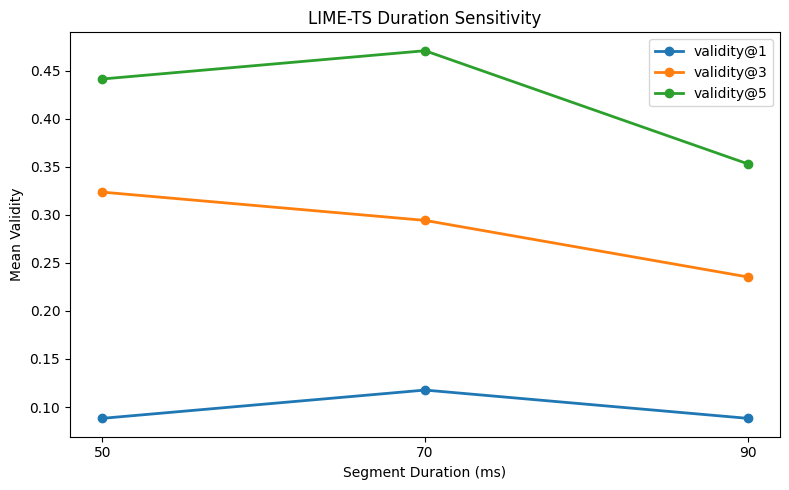

Saved figure → /kaggle/working/figures_common_voice/duration_sensitivity.png


In [80]:
# ============================================================
# CELL 11: Duration Sensitivity with CER Damage Ground Truth
# ============================================================
DUR_CACHE = CACHE_DIR / 'duration_sensitivity.pkl'
DUR_VALUES = [50, 70, 90]
DUR_SUBSET = [u for u in utterances[:50] if len(u.phonemes) > 0 and u.utt_id in asr_results]


def validity_at_k_cer_damage(utt: Utterance, imp: np.ndarray, k_values: List[int]) -> Dict[str, float]:
    if imp is None or len(imp) == 0:
        return {f'validity@{k}': float('nan') for k in k_values}

    damage_scores = get_damage_scores(utt)
    important = important_from_damage(damage_scores, top_fraction=0.10)
    if not important:
        return {f'validity@{k}': float('nan') for k in k_values}

    rank = np.argsort(imp)[::-1]
    return {f'validity@{k}': 1.0 if bool(set(rank[:k]) & important) else 0.0 for k in k_values}


if DUR_CACHE.exists():
    print('Loading cached duration sensitivity results …')
    with open(DUR_CACHE, 'rb') as f:
        dur_records = pickle.load(f)
else:
    dur_records = {}
    print(f'Running duration sensitivity over {len(DUR_SUBSET)} utterances …')
    for dur_ms in DUR_VALUES:
        print(f'\ndur_ms = {dur_ms}')
        expl = LIMEExplainerTS(dur_ms=dur_ms, n_samples=N_SAMPLES_LIME)
        rec_list = []
        for utt in tqdm(DUR_SUBSET, desc=f'LIME-TS {dur_ms}ms'):
            try:
                imp = expl.explain_projected(utt)
                v = validity_at_k_cer_damage(utt, imp, K_VALUES)
                rec_list.append({'utt_id': utt.utt_id, 'gender': utt.gender, **v})
            except Exception as e:
                print(f'{utt.utt_id}: {e}')
            if DEVICE == 'cuda':
                torch.cuda.empty_cache()
            gc.collect()
        dur_records[dur_ms] = pd.DataFrame(rec_list)
        print(f'Collected {len(rec_list)} rows')

    with open(DUR_CACHE, 'wb') as f:
        pickle.dump(dur_records, f)
    print(f'Duration sensitivity cached → {DUR_CACHE}')


dur_summary = []
for dur_ms, df_dur in dur_records.items():
    for k in K_VALUES:
        col = f'validity@{k}'
        val = df_dur[col].dropna().mean() if col in df_dur.columns else float('nan')
        dur_summary.append({'dur_ms': dur_ms, 'k': k, 'validity': val})

dur_sum_df = pd.DataFrame(dur_summary)
display(dur_sum_df.pivot(index='dur_ms', columns='k', values='validity').round(4))

plt.figure(figsize=(8, 5))
for k in K_VALUES:
    subset = dur_sum_df[dur_sum_df['k'] == k].sort_values('dur_ms')
    plt.plot(subset['dur_ms'], subset['validity'], marker='o', linewidth=2, label=f'validity@{k}')
plt.xlabel('Segment Duration (ms)')
plt.ylabel('Mean Validity')
plt.title('LIME-TS Duration Sensitivity')
plt.xticks(DUR_VALUES)
plt.legend()
plt.tight_layout()
fig_path = FIG_DIR / 'duration_sensitivity.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved figure → {fig_path}')


## 10. Qualitative visualization


Generating visualization for: sample-000000
Transcript: without the dataset the article is useless
# phonemes: 36
Saved → /kaggle/working/figures_common_voice/heatmap_sample-000000.png


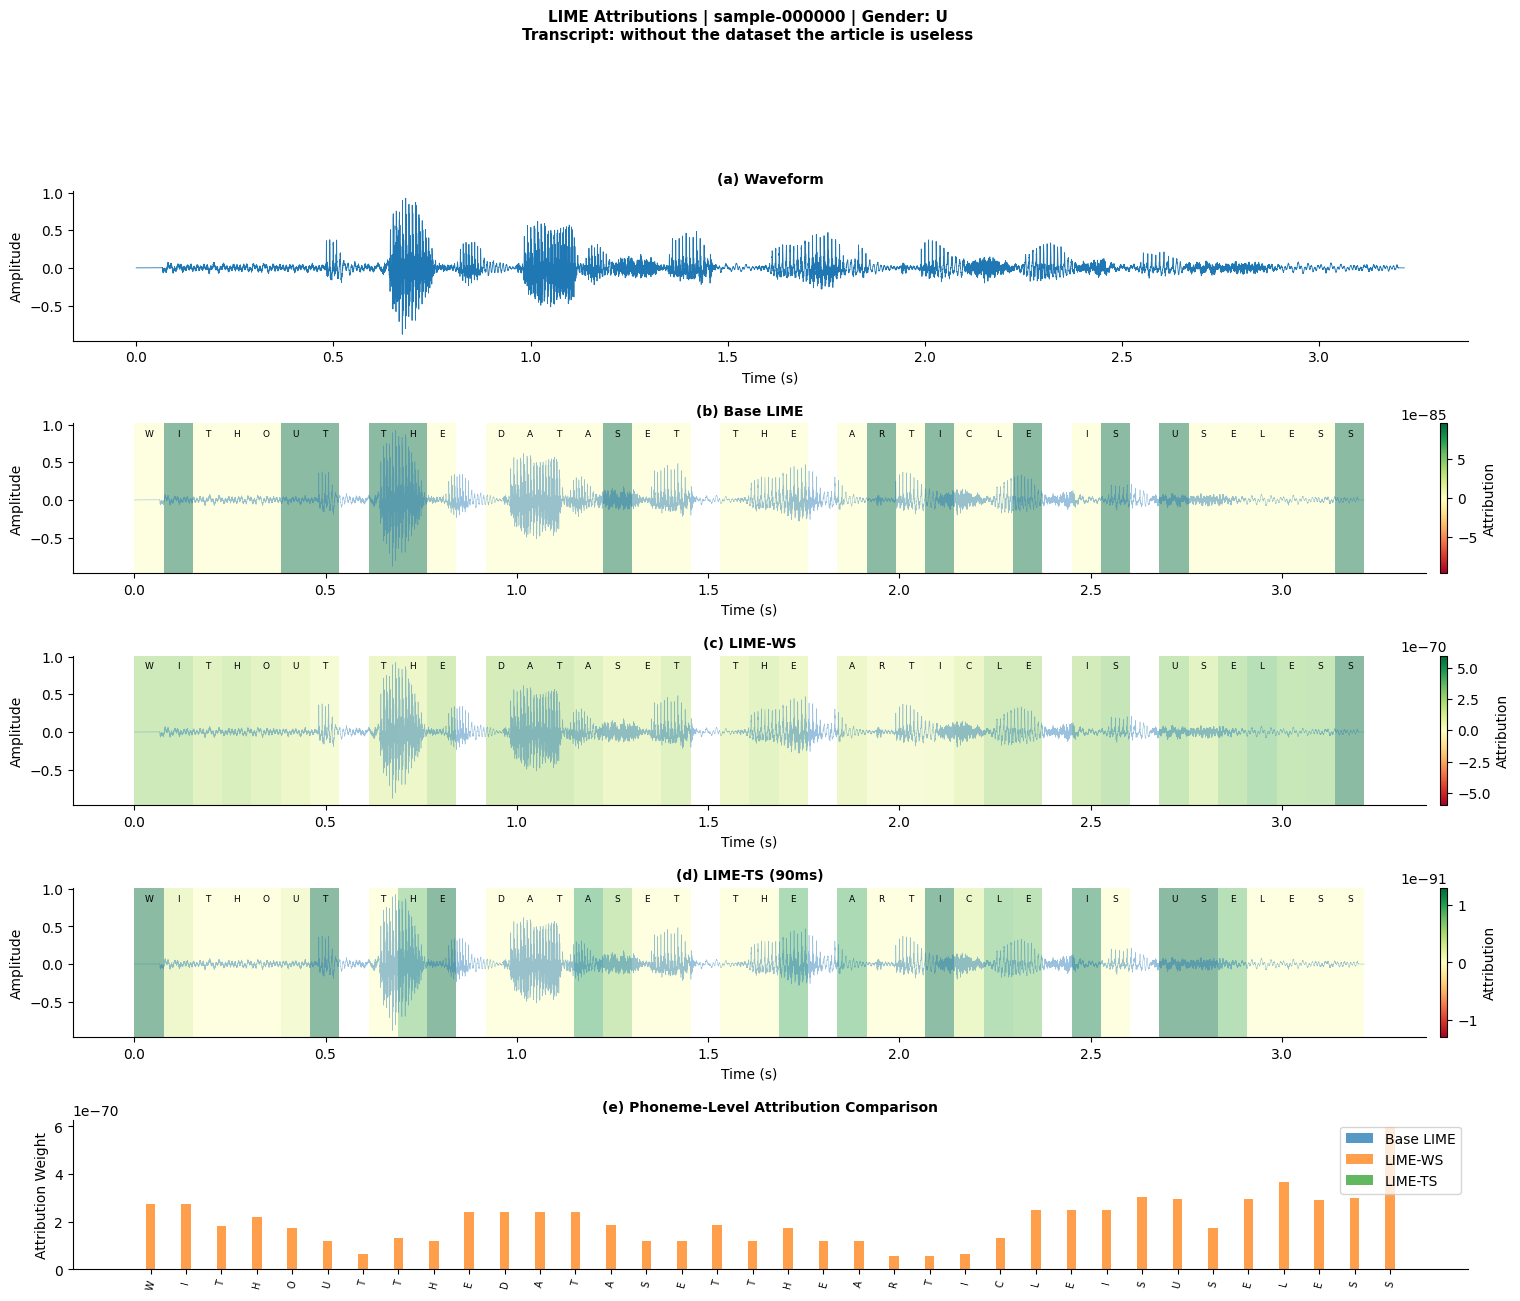

In [81]:
# ============================================================
# CELL 12: Qualitative Attribution Visualization
# ============================================================
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


def visualize_lime_attributions(utt, imp_base, imp_ws, imp_ts, save_path=None, show=True):
    wav = utt.waveform.detach().cpu().numpy()
    t_axis = np.arange(len(wav)) / TARGET_SR
    n_ph = len(utt.phonemes)
    n_s = len(wav)

    def build_heatmap_signal(importances, phonemes, n_samples):
        sig = np.zeros(n_samples)
        if importances is None:
            return sig
        for i, ph in enumerate(phonemes):
            if i >= len(importances):
                break
            s = max(0, int(ph['start'] * TARGET_SR))
            e = min(n_samples, int(ph['end'] * TARGET_SR))
            sig[s:e] = importances[i]
        return sig

    h_b = build_heatmap_signal(imp_base, utt.phonemes, n_s)
    h_ws = build_heatmap_signal(imp_ws, utt.phonemes, n_s)
    h_ts = build_heatmap_signal(imp_ts, utt.phonemes, n_s)

    fig = plt.figure(figsize=(18, 14))
    fig.suptitle(
        f'LIME Attributions | {utt.utt_id} | Gender: {utt.gender}\nTranscript: {utt.transcript[:100]}',
        fontsize=11,
        fontweight='bold',
        y=1.01,
    )
    gs = gridspec.GridSpec(5, 1, hspace=0.55)
    cmap = plt.cm.RdYlGn

    def plot_waveform_heatmap(ax, heatmap, imp_arr, title):
        vabs = np.abs(heatmap).max() or 1.0
        norm = Normalize(vmin=-vabs, vmax=vabs)
        ax.plot(t_axis, wav, alpha=0.45, linewidth=0.4)

        safe_imp = imp_arr if imp_arr is not None else np.array([])
        for ph_i, ph in enumerate(utt.phonemes):
            if ph_i >= len(safe_imp):
                continue
            s = int(ph['start'] * TARGET_SR)
            imp_val = heatmap[s] if 0 <= s < n_s else 0.0
            ax.axvspan(ph['start'], ph['end'], alpha=0.45, color=cmap(norm(imp_val)), linewidth=0)
            mid = (ph['start'] + ph['end']) / 2
            ax.text(mid, ax.get_ylim()[1] * 0.8, ph['label'], ha='center', va='bottom', fontsize=6.5)

        sm = ScalarMappable(norm=norm, cmap=cmap)
        plt.colorbar(sm, ax=ax, fraction=0.02, pad=0.01, label='Attribution')
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Amplitude')
        ax.spines[['top', 'right']].set_visible(False)

    ax0 = fig.add_subplot(gs[0])
    ax0.plot(t_axis, wav, linewidth=0.6)
    ax0.set_title('(a) Waveform', fontsize=10, fontweight='bold')
    ax0.set_ylabel('Amplitude')
    ax0.set_xlabel('Time (s)')
    ax0.spines[['top', 'right']].set_visible(False)

    for gs_slot, hmap, imp_arr, title in [
        (gs[1], h_b, imp_base, '(b) Base LIME'),
        (gs[2], h_ws, imp_ws, '(c) LIME-WS'),
        (gs[3], h_ts, imp_ts, f'(d) LIME-TS ({TS_DUR_MS}ms)'),
    ]:
        ax = fig.add_subplot(gs_slot)
        plot_waveform_heatmap(ax, hmap, imp_arr, title)

    ax4 = fig.add_subplot(gs[4])
    x = np.arange(n_ph)
    w = 0.27
    labels = [ph['label'] for ph in utt.phonemes]

    def safe_bar(imp, offset, label):
        vals = imp[:n_ph] if imp is not None else np.zeros(n_ph)
        ax4.bar(x + offset, vals, w, label=label, alpha=0.75)

    safe_bar(imp_base, -w, 'Base LIME')
    safe_bar(imp_ws, 0, 'LIME-WS')
    safe_bar(imp_ts, w, 'LIME-TS')

    ax4.axhline(0, linewidth=0.6, linestyle='--')
    ax4.set_xticks(x)
    ax4.set_xticklabels(labels, rotation=75, fontsize=7)
    ax4.set_ylabel('Attribution Weight')
    ax4.set_title('(e) Phoneme-Level Attribution Comparison', fontsize=10, fontweight='bold')
    ax4.legend(loc='upper right')
    ax4.spines[['top', 'right']].set_visible(False)

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')
    if show:
        plt.show()
    plt.close(fig)


# Demo on one utterance.
if utterances:
    demo_utt = next((u for u in utterances if len(u.phonemes) > 0 and u.utt_id in asr_results), utterances[0])
    print(f'Generating visualization for: {demo_utt.utt_id}')
    print(f'Transcript: {demo_utt.transcript[:100]}')
    print(f'# phonemes: {len(demo_utt.phonemes)}')

    b_expl = LIMEExplainerBase(n_samples=50)
    ws_expl = LIMEExplainerWS(window=WS_WINDOW, n_samples=50)
    ts_expl = LIMEExplainerTS(dur_ms=TS_DUR_MS, n_samples=50)

    imp_b = b_expl.explain(demo_utt)
    imp_w = ws_expl.explain_and_project(demo_utt)
    imp_t = ts_expl.explain_projected(demo_utt)

    visualize_lime_attributions(
        demo_utt,
        imp_b,
        imp_w,
        imp_t,
        save_path=FIG_DIR / f'heatmap_{demo_utt.utt_id}.png',
        show=True,
    )


## 11. Cache reset helper

Run this only when you intentionally want to remove saved outputs and recompute from scratch.


In [ ]:
# ============================================================
# OPTIONAL: Clear cache for a fresh rerun
# ============================================================
# Uncomment and run if needed.

# for f in [
#     'alignments.pkl',
#     'asr_results.pkl',
#     'validity_results.pkl',
#     'validity_checkpoint.pkl',
#     'validity_checkpoint.csv',
#     'duration_sensitivity.pkl',
# ]:
#     p = CACHE_DIR / f
#     if p.exists():
#         p.unlink()
#         print(f'Deleted {f}')
#
# for name in ['utterances', 'asr_results', 'df_v', 'eval_df']:
#     if name in globals():
#         del globals()[name]
